In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'test': 1}

In [3]:
TEST_NUM = OPTIONS['test']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [4]:
TARGET_VAR  = 'pitch'
LIMITS      = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [15, 600], 'static': [700, 999999999]}
[700, 999999999]
[15, 600]


# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df['time']   = (df.time - df.time.values[0])
df['static'] = (df.time > STATIC_LIMITS[0])
df

,ay,roll,wx,pitch,time,wz,yaw,wy,ax,tmp,az,static
0,13996,-161,-30992,788,0.000000,552,359927,-36482,1939,33.4,993914,False
1,15543,-161,-29919,800,0.064848,-4607,359925,14407,597,33.4,998087,False
2,16488,-161,-1012,811,0.168181,-27448,359920,-17971,6305,33.3,996489,False
3,14028,-155,-67665,822,0.269503,14319,359917,-52724,1990,33.6,998901,False
4,16099,-154,-14749,832,0.368434,7764,359916,-2812,1520,33.4,995903,False
...,...,...,...,...,...,...,...,...,...,...,...,...
431977,24415,-141,-11754,1415,43199.403495,-19151,274238,-4712,3694,61.1,996553,True
431978,27443,-140,6235,1417,43199.512243,14773,274239,49627,908,61.3,995085,True
431979,27975,-141,20572,1415,43199.609807,17914,274239,17441,-2184,61.3,999752,True
431980,24235,-141,37387,1416,43199.704816,-18711,274239,-32080,2904,61.3,1000165,True


- Convertendo pra radianos

In [6]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,ay,roll,wx,pitch,time,wz,yaw,wy,ax,tmp,az,static
0,0.137254,-0.161,-0.30992,0.788,0.000000,0.00552,359.927,-0.36482,0.019015,33.4,9.746967,False
1,0.152425,-0.161,-0.29919,0.800,0.064848,-0.04607,359.925,0.14407,0.005855,33.4,9.787890,False
2,0.161692,-0.161,-0.01012,0.811,0.168181,-0.27448,359.920,-0.17971,0.061831,33.3,9.772219,False
3,0.137568,-0.155,-0.67665,0.822,0.269503,0.14319,359.917,-0.52724,0.019515,33.6,9.795872,False
4,0.157877,-0.154,-0.14749,0.832,0.368434,0.07764,359.916,-0.02812,0.014906,33.4,9.766472,False


- Formatando as colunas pra ficar igual a de referência

In [7]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,ay,roll,wx,pitch,time,wz,yaw,wy,ax,tmp,az,static
0,9.746967,0.788,-0.30992,0.161,0.000000,-0.36482,359.927,-0.00552,0.019015,33.4,0.137254,False
1,9.787890,0.800,-0.29919,0.161,0.064848,0.14407,359.925,0.04607,0.005855,33.4,0.152425,False
2,9.772219,0.811,-0.01012,0.161,0.168181,-0.17971,359.920,0.27448,0.061831,33.3,0.161692,False
3,9.795872,0.822,-0.67665,0.155,0.269503,-0.52724,359.917,-0.14319,0.019515,33.6,0.137568,False
4,9.766472,0.832,-0.14749,0.154,0.368434,-0.02812,359.916,-0.07764,0.014906,33.4,0.157877,False


In [8]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,ay,roll,wx,pitch,time,wz,yaw,wy,ax,tmp,az,static
77020,9.799697,1.425,0.15651,0.139,0.0,0.09404,344.816,-0.00008,0.014867,59.3,0.230996,False
124682,9.794598,1.424,0.04861,0.135,0.0,-0.05808,332.990,-0.05766,0.018034,60.5,0.232045,False
165054,9.774514,1.419,0.42552,0.128,0.0,-0.03730,321.082,-0.17243,0.008640,60.2,0.254473,False
204966,9.801806,1.439,-0.12128,0.138,0.0,0.05505,313.351,-0.07181,0.008669,61.1,0.290855,False
244241,9.800080,1.416,0.02390,0.141,0.0,-0.12928,306.688,-0.01390,0.012435,61.1,0.222954,False
276574,9.777740,1.416,-0.00764,0.145,0.0,0.32561,301.833,-0.05339,0.015279,61.3,0.233232,False
317356,9.728766,1.420,-0.11160,0.135,0.0,0.18369,294.180,-0.18422,0.004884,61.3,0.222464,False
354749,9.791528,1.420,0.08941,0.145,0.0,-0.00063,287.105,0.27020,-0.000284,61.4,0.230348,False
391207,9.762912,1.424,0.47342,0.146,0.0,-0.31212,280.757,-0.16075,0.043404,61.4,0.197849,False
428881,9.820615,1.420,0.02290,0.149,0.0,0.09538,274.721,-0.05481,-0.005737,61.3,0.239272,False


# VISUALIZAÇÃO DE VARIÁVEIS

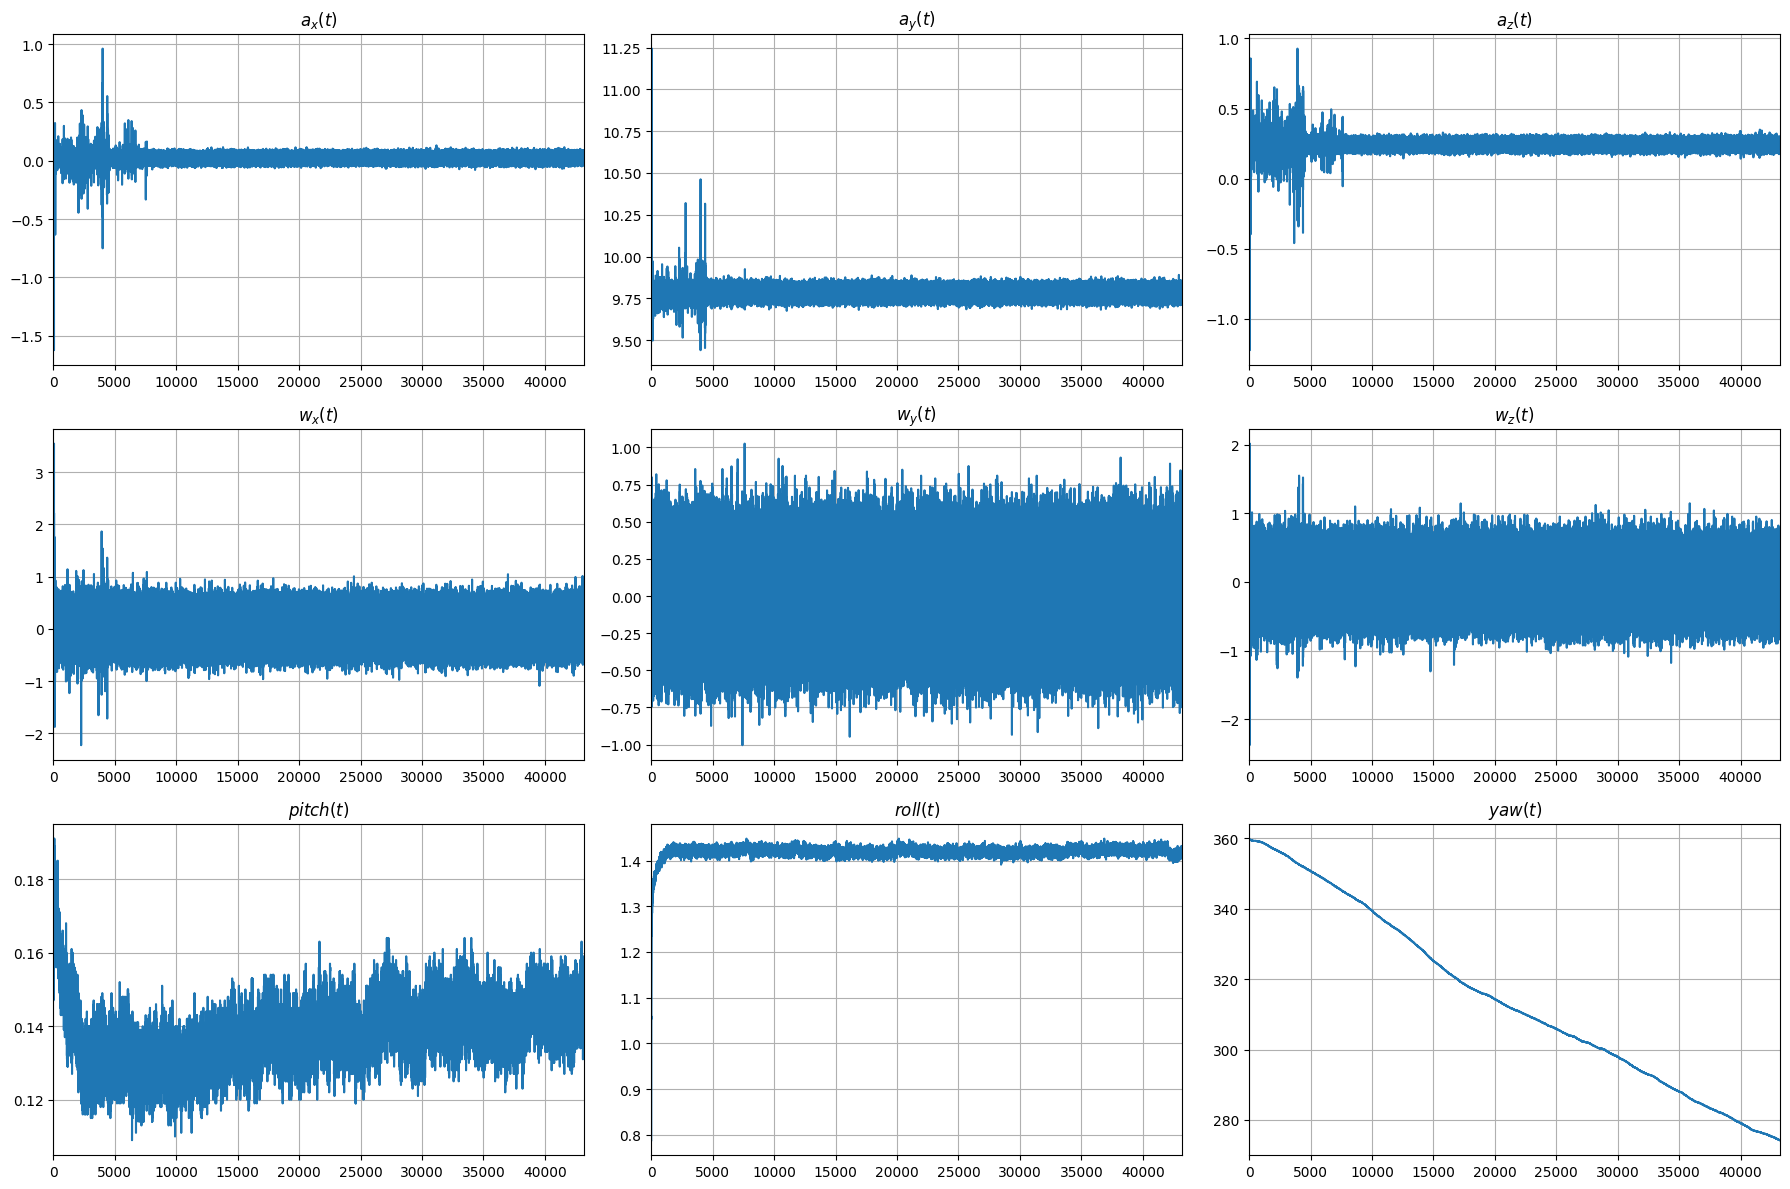

In [9]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

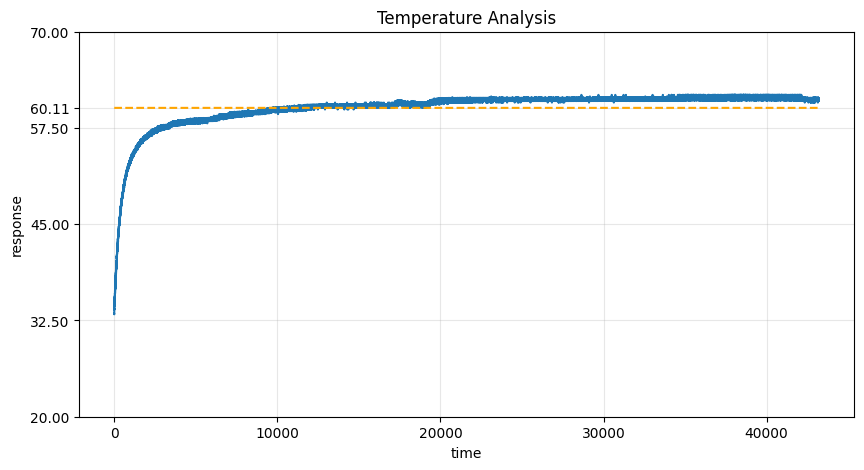

In [10]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

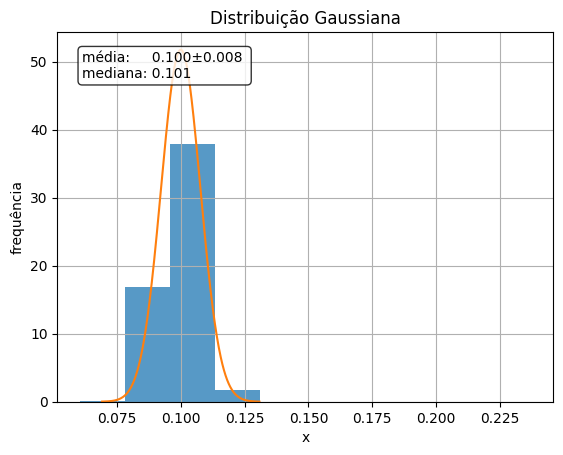

In [11]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [12]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,ay,roll,wx,pitch,wz,yaw,wy,ax,tmp,az,static
0,0.0,9.746967,0.788,-0.30992,0.161,-0.36482,359.927,-0.00552,0.019015,33.4,0.137254,False
1,0.1,9.787890,0.800,-0.29919,0.161,0.14407,359.925,0.04607,0.005855,33.4,0.152425,False
2,0.2,9.772219,0.811,-0.01012,0.161,-0.17971,359.920,0.27448,0.061831,33.3,0.161692,False
3,0.3,9.795872,0.822,-0.67665,0.155,-0.52724,359.917,-0.14319,0.019515,33.6,0.137568,False
4,0.4,9.766472,0.832,-0.14749,0.154,-0.02812,359.916,-0.07764,0.014906,33.4,0.157877,False
...,...,...,...,...,...,...,...,...,...,...,...,...
431994,43199.4,9.827430,1.415,-0.05064,0.138,-0.08800,274.238,-0.19570,0.018809,61.1,0.246922,True
431995,43199.5,9.772846,1.415,-0.11754,0.141,-0.04712,274.238,0.19151,0.036226,61.1,0.239429,True
431996,43199.6,9.758450,1.417,0.06235,0.140,0.49627,274.239,-0.14773,0.008904,61.3,0.269124,True
431997,43199.7,9.804218,1.415,0.20572,0.141,0.17441,274.239,-0.17914,-0.021418,61.3,0.274341,True


# FILTRANDO POR VARIAVEL

In [13]:
df = df.loc[(df.time >= DYNAMIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])]
df.loc[:, 'time'] = (df.time - df.time.values[0])

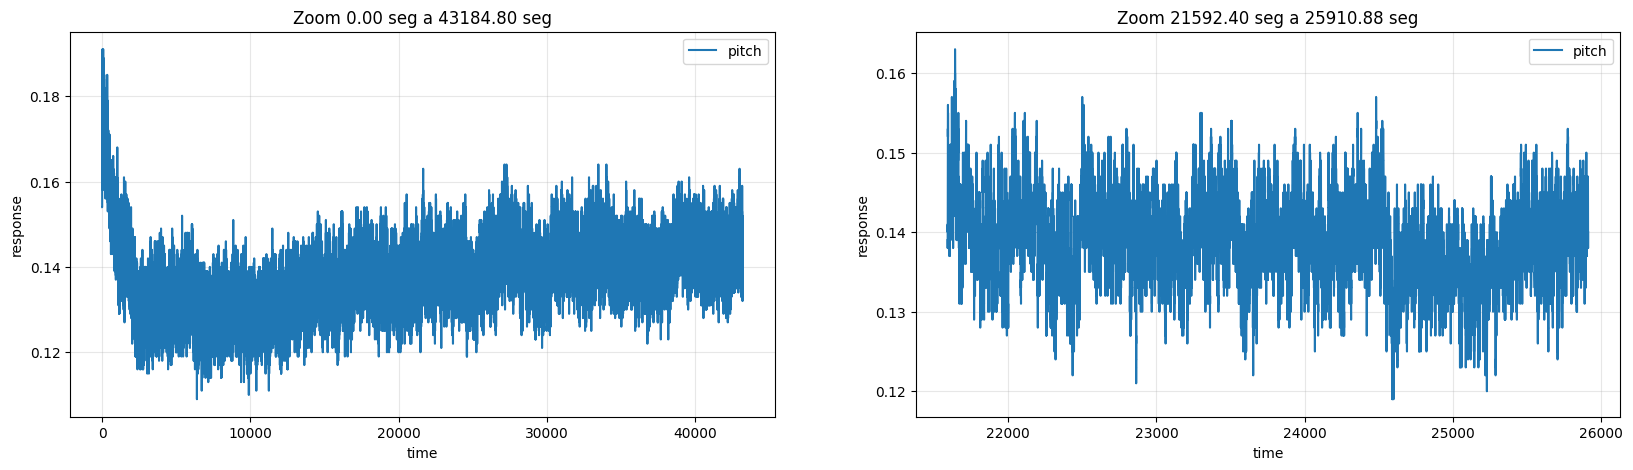

In [14]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [15]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_ay,target_roll,target_wx,target_pitch,target_wz,target_yaw,target_wy,target_ax,target_tmp,target_az,static
150,0.0,9.737680,1.108,0.06179,0.154,-0.66750,359.823,-0.12855,-0.142746,34.5,0.144579,False
151,0.1,9.830108,1.108,-0.24387,0.154,0.19358,359.822,-0.08491,0.012837,34.7,0.203351,False
152,0.2,9.793529,1.108,0.24506,0.159,0.14292,359.822,-0.06904,0.011297,34.7,0.186503,False
153,0.3,9.795863,1.110,-0.22525,0.164,0.40590,359.821,-0.22769,0.079149,34.7,0.178510,False
154,0.4,9.839875,1.112,0.17356,0.169,0.18466,359.820,-0.10012,0.028116,34.7,0.220346,False
...,...,...,...,...,...,...,...,...,...,...,...,...
431994,43184.4,9.827430,1.415,-0.05064,0.138,-0.08800,274.238,-0.19570,0.018809,61.1,0.246922,True
431995,43184.5,9.772846,1.415,-0.11754,0.141,-0.04712,274.238,0.19151,0.036226,61.1,0.239429,True
431996,43184.6,9.758450,1.417,0.06235,0.140,0.49627,274.239,-0.14773,0.008904,61.3,0.269124,True
431997,43184.7,9.804218,1.415,0.20572,0.141,0.17441,274.239,-0.17914,-0.021418,61.3,0.274341,True


In [16]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)